# Forecasting Project

In [1]:
## Dependencies
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import boxcox
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holt-Winters triple exponential smoothing (level + trend + seasonality)
from statsmodels.tsa.statespace.sarimax import SARIMAX

### 1. Acquiring datasets

In [2]:
# NVIDIA dataset:
nvidia = yf.download("NVDA", start="2020-01-01", end="2026-07-01")
nvidia.columns = nvidia.columns.get_level_values(0)
nvidia.columns.name = None # removing title of column names.
nvidia.reset_index(inplace=True) # resetting index to have date as a column.

nvidia["Date"] = pd.to_datetime(nvidia["Date"]) # date column as Date.
nvidia.head(5)


[*********************100%***********************]  1 of 1 completed

,Date,Close,High,Low,Open,Volume
0,2020-01-02,5.963804,5.963804,5.884506,5.934969,237536000
1,2020-01-03,5.868346,5.912097,5.819374,5.844233,205384000
2,2020-01-06,5.892958,5.898178,5.749027,5.775129,262636000
3,2020-01-07,5.964300,6.010040,5.876301,5.921295,314856000
4,2020-01-08,5.975489,6.016754,5.920054,5.960076,277108000


In [3]:
# Semiconductor billing dataset:
sia = pd.read_csv('americas_semiconductor_billings.csv') # one value per month; low granularity compared to nvidia dataset.
sia["Date"] = pd.to_datetime(sia["Date"])
sia.head(5)

/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_49695/2856192465.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sia["Date"] = pd.to_datetime(sia["Date"])


,Date,Value
0,2026-05-31,46.42M
1,2026-04-30,41.53M
2,2026-03-31,40.60M
3,2026-02-28,36.20M
4,2026-01-31,24.63M


In [4]:
# Merging:
merged = pd.merge(
    nvidia,
    sia[["Date", "Value"]],
    on="Date",
    how="left" # keep the all dates form nvidia set.
)

merged["Value"] = merged["Value"].fillna("")

## Output:
display(merged[merged["Value"] != ""].head(5)) # value column filled only at end of month.
display(merged.head(10))

,Date,Close,High,Low,Open,Volume,Value
607,2022-05-31,18.616377,19.142804,18.295336,18.923458,664100000,12.61M
628,2022-06-30,15.117030,15.523901,14.820853,15.318471,686070000,12.10M
671,2022-08-31,15.052212,15.496977,14.917585,15.341409,573710000,11.52M
692,2022-09-30,12.108991,12.601770,12.045149,12.057119,565638000,13.77M
713,2022-10-31,13.463634,13.803791,13.264128,13.743939,486341000,11.69M


,Date,Close,High,Low,Open,Volume,Value
0,2020-01-02,5.963804,5.963804,5.884506,5.934969,237536000,
1,2020-01-03,5.868346,5.912097,5.819374,5.844233,205384000,
2,2020-01-06,5.892958,5.898178,5.749027,5.775129,262636000,
3,2020-01-07,5.964300,6.010040,5.876301,5.921295,314856000,
4,2020-01-08,5.975489,6.016754,5.920054,5.960076,277108000,
5,2020-01-09,6.041114,6.113452,5.987420,6.061746,255112000,
6,2020-01-10,6.073430,6.178582,6.059261,6.148254,316296000,
7,2020-01-13,6.263846,6.288953,6.133836,6.156457,319840000,
8,2020-01-14,6.147010,6.246444,6.133834,6.221088,359088000,
9,2020-01-15,6.104502,6.182060,6.078649,6.159688,263104000,


### 2. Data Inspection

In [5]:
# Inspecting and cleaning time series data

## Date as index in both datasets:
sia.set_index("Date", inplace=True)
nvidia.set_index("Date", inplace=True)


In [6]:
## Duplicates
print(sia.duplicated().sum()) # 1 potential duplicate in sia.
print(nvidia.duplicated().sum())

1
0


In [7]:
sia[sia["Value"].duplicated(keep=False)] # duplicate is just the value in different months; duplicate should NOT be removed.

,Value
Date,
2025-03-31,20.71M
2024-11-30,20.71M


In [8]:
## Null
nvidia.isnull().sum()
sia.isnull().sum()
# NONE

Value    0
dtype: int64

In [9]:
## Differences in time stamps (now, index)
nvidia.index.to_series().diff().value_counts()

Date
1 days    1276
3 days     291
4 days      48
2 days      15
Name: count, dtype: int64

In [10]:
## month-end data from nividia:
nvidia_monthly = nvidia.resample("ME").last()
nvidia_monthly.head(5)

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-31,5.877296,6.076661,5.835534,6.064729,370420000
2020-02-29,6.717552,6.776999,6.014133,6.030798,1133252000
2020-03-31,6.556622,6.850127,6.411112,6.646165,949960000
2020-04-30,7.269989,7.423706,7.256060,7.369731,375916000
2020-05-31,8.830545,8.830545,8.442023,8.511171,745256000


### 2a. Feature Engineering

In [11]:
# turning Value from string to numeric:
sia["Value_num"] = sia["Value"].str.replace("M", "", regex=False)

sia["Value_num"] = pd.to_numeric(sia["Value_num"])

## Defining for other work downstream:
nvidia_new = nvidia
sia_new = sia

In [12]:
# Lagging by one day:
nvidia["Close_lag1"] = nvidia["Close"].shift(1)
nvidia["Close_lag2"] = nvidia["Close"].shift(2)

sia["Value_lag1"] = sia["Value_num"].shift(1)
sia["Value_lag2"] = sia["Value_num"].shift(2)

In [13]:
# Rolling statistics: helps capture short-term trends
## Rolling averages, e.g.: how mean sales change over a rolling 5-day period?

nvidia["rolling_mean_3"] = nvidia["Close"].rolling(3).mean()
nvidia["rolling_sd_3"] = nvidia["Close"].rolling(3).std()

sia["rolling_mean_3"] = sia["Value_num"].rolling(3).mean()
sia["rolling_sd_3"] = sia["Value_num"].rolling(3).std()

In [14]:
# Expanding Window features:
## For 'cumulative' information
nvidia["expanding_mean"] = nvidia["Close"].expanding().mean() # cumulative/'expanding' mean per row, i.e. mean of row 1, mean of rows 1 and 2, and so on.
sia["expanding_mean"] = sia["Value_num"].expanding().mean()

In [15]:
# % change feature:
nvidia["return"] = nvidia["Close"].pct_change() # pct(%) change in Close value from previous row (lag of 1 is default)
sia["Value_growth"] = sia["Value_num"].pct_change()

In [16]:
# Date component extraction:
nvidia["Year"] = nvidia.index.year
nvidia["Month"] = nvidia.index.month

sia["Year"] = sia.index.year
sia["Month"] = sia.index.month

### 2b. Merging Multi-Source Data

In [17]:
# Merging datasets:

## a common column that captures the year and month (Y-m), by capturing the monthly frequency, i.e. to_period("M")
nvidia["YM"] = nvidia.index.to_period("M")
sia["YM"] = sia.index.to_period("M")

final = pd.merge(nvidia.reset_index(), sia.reset_index(), # turns index (or Date) into a dataset column => required for merging
                 on="YM",
                 how="inner") # keeps the months that appear in both datasets in 'final'

### 3. Transformations

In [18]:
# removing duplicates in both datasets:
nvidia.duplicated(subset="YM").sum() # 1553 of nvidia
sia.duplicated(subset="YM").sum()

nvidia = nvidia.drop_duplicates(subset="YM")
sia = sia.drop_duplicates(subset="YM")

In [19]:
### double check:
nvidia["YM"][~nvidia.duplicated(subset="YM")].head() # ~ negates the mask => the first (non-duplicate) row of each month

Date
2020-01-02    2020-01
2020-02-03    2020-02
2020-03-02    2020-03
2020-04-01    2020-04
2020-05-01    2020-05
Name: YM, dtype: period[M]

In [20]:
# Merging for new final df:
final = pd.merge(nvidia.reset_index(),
                 sia.reset_index(),
                 on="YM",
                 how="inner")

In [21]:
# Transformations: Log, Box-Cox, Differencing
## AIM: To NORMALISE the distribution of data
# Reshape/rescale the data so it meets model assumptions: stabilise variance (e.g. log),
# put features on a comparable scale (normalise/standardise), and remove trend/seasonality
# to make the series stationary => cleaner signal and better-behaved, more accurate models.

########################
# 1. Log Transformation:
final["log_Close"] = np.log(final["Close"])
final["log_Value"] = np.log(final["Value_num"])

# 2. Box-Cox Transformation
## lam (lambda) = the power boxcox picks to best normalise the data (0=log, 0.5=sqrt, 1=no transform).
## boxcox only works on POSITIVE values.
final["boxcox_Close"], lam = boxcox(final["Close"])

# 3. First Differencing
## each value minus the previous one (value[t] - value[t-1]) => removes trend to make the series stationary.
final["diff_Close"] = final["Close"].diff()
final["diff_Value"] = final["Value_num"].diff()

# 4. Seasonal Differencing
## each value minus the one m periods earlier (value[t] - value[t-m]) => removes a repeating seasonal cycle.
final["seasonal_diff_Close"] = final["Close"].diff(12) # yearly difference

## FINAL: drop na rows, for complete dataset
final = final.dropna()

### 4. Forecast Evaluation Metrics

#### Useful for picking up on Anomalies = unexpected drops or spikes in data.

In [22]:
# MAE = Mean Absolute Error; simple metric.
# RMSE = Root Mean of Squared Errors; Punishes big errors.
# MAPE = Mean Absolute Percentage Error; error as a % of actuals, so scale-independent, i.e.: a %, not data units => comparable across differently-sized series.

## Feature Engineering

### 5. Visualizing Trends & Patterns

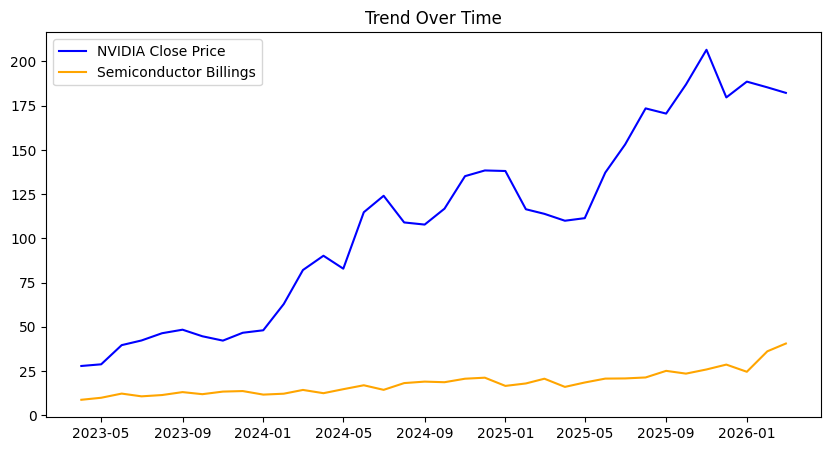

In [23]:
# time series split
## Line Plot:
final['YM'] = final['YM'].dt.to_timestamp() # Y-M is now continuous, so can be plotted on x-axis as a time series.

## OUTPUT:
plt.figure(figsize=(10,5))
plt.plot(final['YM'], final['Close'], label='NVIDIA Close Price', color='blue')
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')
plt.legend()
plt.title("Trend Over Time")
plt.show()

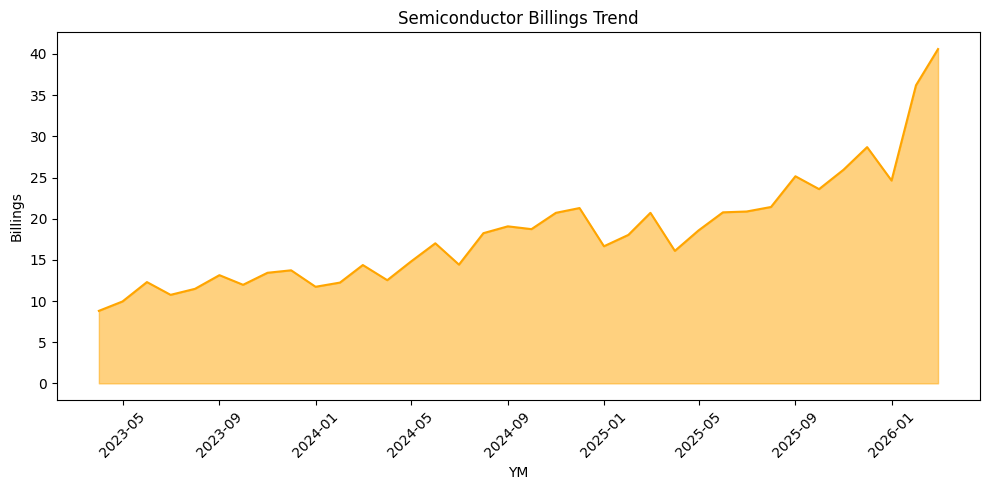

In [24]:
## Billings Trend:
plt.figure(figsize=(10,5))
plt.fill_between(final['YM'], final['Value_num'], color='orange', alpha=0.5)
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')

plt.title("Semiconductor Billings Trend")
plt.xlabel("YM")
plt.ylabel("Billings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

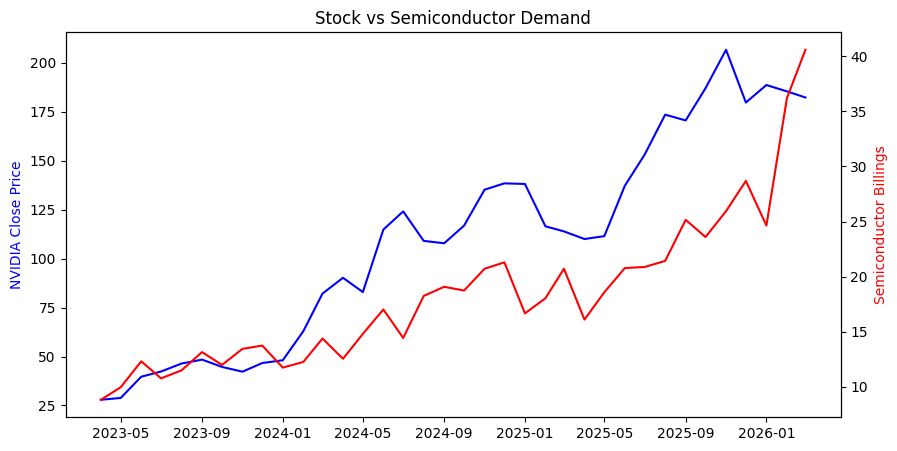

In [25]:
## Dual axis:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(final['YM'], final['Close'], color='blue')
ax1.set_ylabel('NVIDIA Close Price', color='blue')

ax2 = ax1.twinx() # second y-axis sharing the same x-axis => plots billings (different scale) alongside Close.
ax2.plot(final['YM'], final['Value_num'], color='red')
ax2.set_ylabel('Semiconductor Billings', color='red')

plt.title("Stock vs Semiconductor Demand")
plt.show()

# Allows for between-parameter (y-axis) comparisons.

### 5a. Seasonal Decomposition = breaking into smaller meaningful chunks

In [26]:
# Components: Trend (long-term direction), Seasonality (repeating patterns), and Residuals (random noise).

final['Date_x'] = pd.to_datetime(final['Date_x']) # ensures Date is in datetime format for plotting.
final = final.sort_values('Date_x') # sorts the dataframe by date in ascending order.

final.set_index('Date_x', inplace=True) # date is now index.


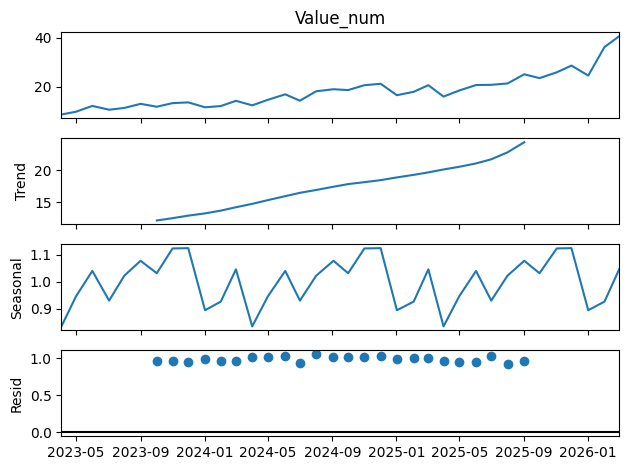

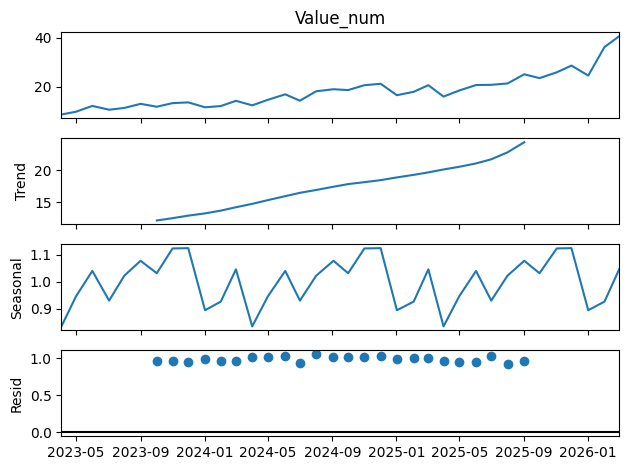

In [27]:
# Decomposition
## for the SIA data of Value_num, which is monthly and has a clear seasonal pattern.

sia_result = seasonal_decompose( # splits the series into trend + seasonal + residual components
    final['Value_num'], # the series being decomposed (semiconductor billings)
    model = 'multiplicative', # components multiply (trend * seasonal * resid); used when seasonal swings grow with the trend
    period=12 # length of one seasonal cycle: 12 => yearly pattern in monthly data
)

sia_result.plot() # plots the original series + the 3 extracted components stacked


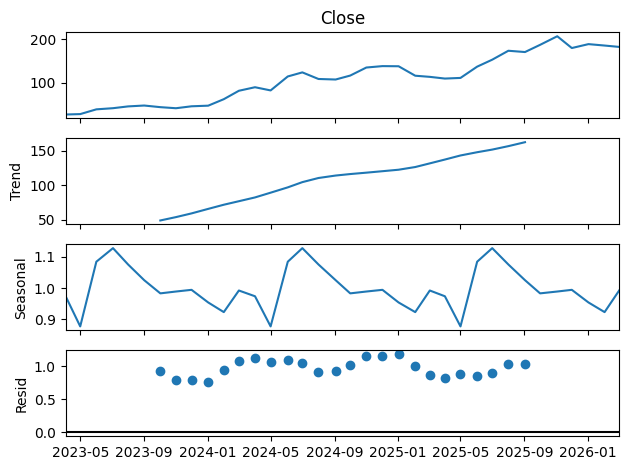

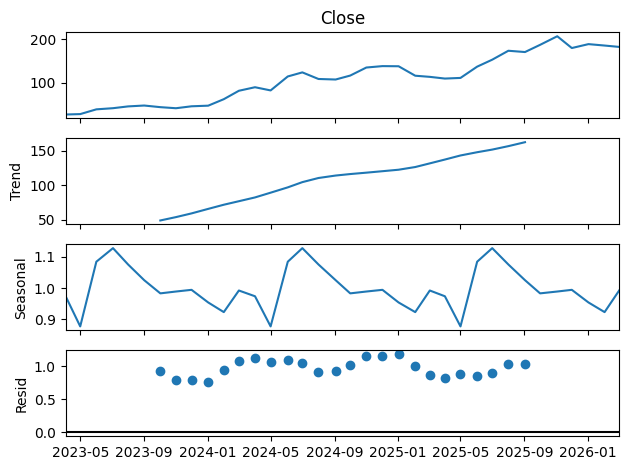

In [28]:
## for NVIDIA stok data:
nvda_result = seasonal_decompose(
    final['Close'],
    model='multiplicative',
    period=12
)

nvda_result.plot()

**Why `multiplicative` (not `additive`)?**

- **Additive**: $y_t = T_t + S_t + R_t$ — seasonal swings stay a **constant size** over time.
- **Multiplicative**: $y_t = T_t \times S_t \times R_t$ — seasonal swings **scale with the level** of the series.

(where $T_t$ = trend, $S_t$ = seasonal, $R_t$ = residual)

Billings trend upward and their seasonal swings grow with that level => multiplicative fits better.


**The three components:**

- **Trend ($T_t$)** — the long-term direction of the series (overall rise or fall), stripped of short-term wiggles.
- **Seasonal ($S_t$)** — the repeating cycle of fixed length (here the yearly pattern from `period=12`).
- **Residual ($R_t$)** — whatever is left after removing trend and seasonal: the irregular "noise" the model can't explain.

The aim is **not** to minimise the residual by choice — it's a <u>diagnostic</u>, not a knob. A good decomposition leaves a residual that is small and **patternless** (random, hovering around 1 for multiplicative). Leftover structure in the residual means the trend/seasonal fit missed something.


### Best technique for decomposition: 
#### STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)

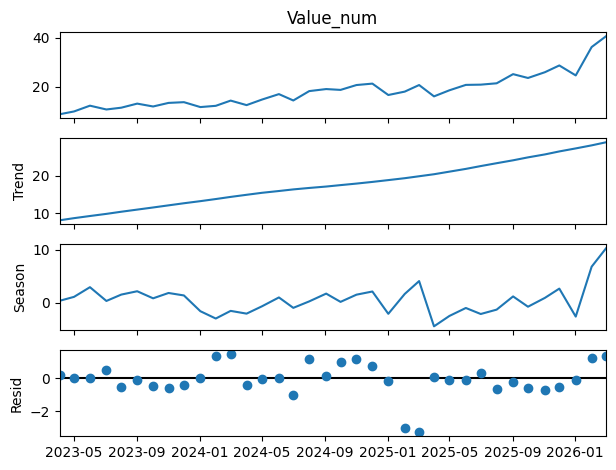

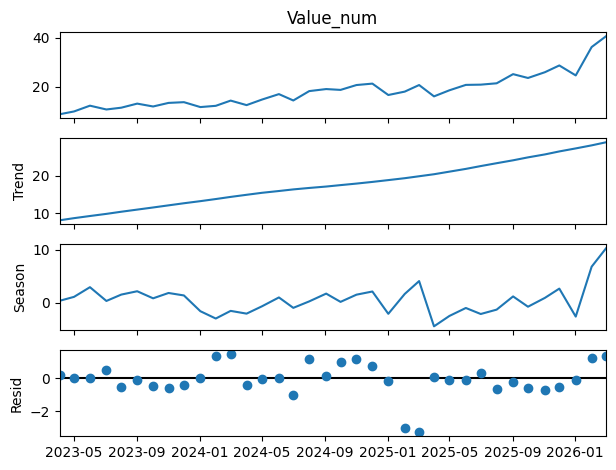

In [29]:
# STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)
## Splits the series into trend + seasonal + residual (like seasonal_decompose),
## but uses LOESS smoothing => the seasonal shape can slowly change over time and it handles outliers better.

## >Therefore, seasonality does not have to be a strictly repeating pattern, and can change over time (e.g. due to changing market conditions).

stl_sia = STL(final['Value_num'], period=12).fit()
stl_sia.plot()

### 5b. Stationarity Testing (mean & std) - ADF & KPSS

##### Stationarity:
 A series is STATIONARY if its statistical properties stay constant over time:
 - constant mean (no trend)
 - constant variance (spread doesn't grow/shrink)
 - autocorrelation depends only on the lag (gap between points), not on when you look.

 **Why it matters:** most forecasting models (e.g. ARIMA) ASSUME stationarity => a stable pattern they can learn and project forward. Trend/seasonality break this, which is why we transform/difference the data first.

 ADF & KPSS are hypothesis tests that formally check whether the series is stationary.

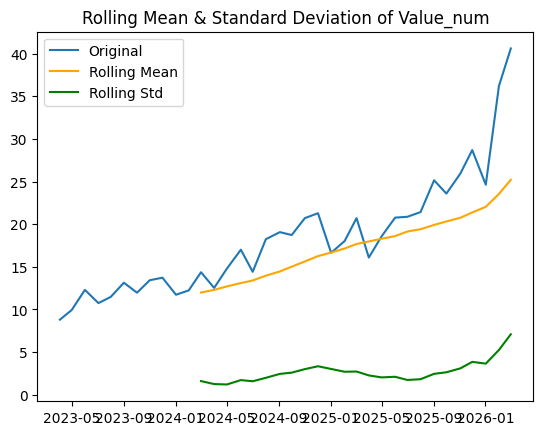

In [30]:
# Visualize:

rolling_mean = final['Value_num'].rolling(window=12).mean() # 12-month rolling mean
rolling_std = final['Value_num'].rolling(window=12).std() # 12-month rolling standard deviation

plt.plot(final['Value_num'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='orange')
plt.plot(rolling_std, label='Rolling Std', color='green')
plt.legend()
plt.title('Rolling Mean & Standard Deviation of Value_num')
plt.show()

# Mean and Std are increasing over time = No stationarity.

In [31]:
# Statistical test for stationarity: Augmented Dickey-Fuller (ADF) test

adf_result = adfuller(final['Value_num']) # returns a tuple of test statistic, p-value, and critical values

print(f"ADF statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")
if adf_result[1] < 0.05:
    print("The series is stationary (reject H0)")
else:
    print(f"The series is non-stationary (p = {adf_result[1]:.3f})")


ADF statistic: 1.209
p-value: 0.996
The series is non-stationary (p = 0.996)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_49695/866624036.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(final['Value_num']) # returns a tuple of test statistic, p-value, and critical values


In [32]:
# Statistical test for stationarity: KPSS test
## NOTE: KPSS reverses the hypotheses vs ADF => here H0 = STATIONARY.
## So p < 0.05 means REJECT stationarity (non-stationary); p >= 0.05 means stationary.

kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)

print(f"KPSS statistic: {kpss_result[0]:.3f}")
print(f"p-value: {kpss_result[1]:.3f}")
if kpss_result[1] < 0.05:
    print(f"The series is non-stationary (reject H0, p = {kpss_result[1]:.3f})")
else:
    print(f"The series is stationary (p = {kpss_result[1]:.3f})")


KPSS statistic: 0.926
p-value: 0.010
The series is non-stationary (reject H0, p = 0.010)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_49695/2310657812.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)
/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_49695/2310657812.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)


**The test equations**

**ADF** — regression: $\;\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \varepsilon_t\;$; statistic $= \hat{\gamma} / \text{SE}(\hat{\gamma})$.
- H0: $\gamma = 0$ (non-stationary) vs H1: $\gamma < 0$ (stationary). Small p => stationary.
- *Intuition:* 
$\gamma = 0$ => the change doesn't depend on $y_{t-1}$, so the series has no pull back to a mean => a **random walk (non-stationary)**. 
$\gamma < 0$ => high values get pushed down / low values up => **mean reversion (stationary)**. So it's a *negative* relationship, not just any, that means stationary.

**KPSS** — statistic: $\;\text{KPSS} = \dfrac{1}{T^2} \sum_{t=1}^{T} S_t^{\,2} / \hat{\sigma}^2\;$, where $S_t = \sum_{i=1}^{t} \hat{\varepsilon}_i$ (cumulative residuals), $\hat{\sigma}^2$ = long-run variance.
- H0: stationary vs H1: non-stationary (**reverse of ADF**). Small p => non-stationary.


In [33]:
# Returns = change in close between y(t) and y(t-1).
final['Returns'] = final['Close'].pct_change() # pct(%) change in Close value from previous row (lag of 1 is default)

final = final.dropna()

adf_res = adfuller(final['Returns'])

print(f"ADF statistic: {adf_res[0]:.3f}")
print(f"p-value: {adf_res[1]:.3f}")
if adf_res[1] < 0.05:
    print("The series is stationary (reject H0)")
else:
    print(f"The series is non-stationary (p = {adf_res[1]:.3f})")


ADF statistic: -4.967
p-value: 0.000
The series is stationary (reject H0)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_49695/1559166795.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(final['Returns'])


In [34]:
# If data is 'Non-Stationary', transformations needed.

## Differencing:
final['Value_diff'] = final['Value_num'].diff() # first differencing to remove trend and make series stationary
final_test = final.dropna()

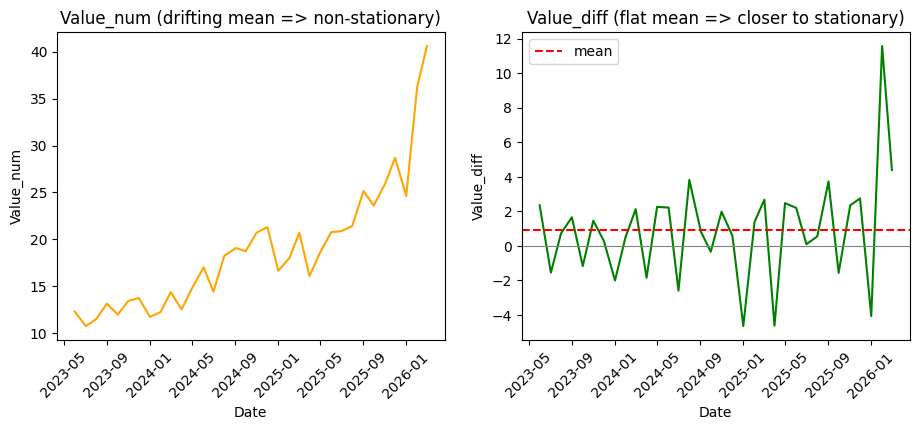

In [35]:
# How differencing removes trend: Value_num (trending) vs Value_diff (detrended)
## Value_diff = Value_num[t] - Value_num[t-1] => a linear trend cancels, leaving changes around a constant mean.

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(final_test.index, final_test['Value_num'], color='orange')
ax[0].set_title("Value_num (drifting mean => non-stationary)")
ax[0].set_xlabel("Date"); ax[0].set_ylabel("Value_num")
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(final_test.index, final_test['Value_diff'], color='green')
ax[1].axhline(final_test['Value_diff'].mean(), color='red', ls='--', label='mean') # roughly flat mean
ax[1].axhline(0, color='grey', lw=0.8)
ax[1].set_title("Value_diff (flat mean => closer to stationary)")
ax[1].set_xlabel("Date"); ax[1].set_ylabel("Value_diff")
ax[1].tick_params(axis='x', rotation=45); ax[1].legend()

#plt.tight_layout()
plt.show()

### 5b. Stationarity Testing (Autocorrelation) - ACF & PACF

**Why autocorrelation analysis?**

**Autocorrelation** = how strongly a value correlates with its own past values at a given lag. It reveals the **memory/structure** in the series: which past lags still carry signal about the present.

- **ACF (Autocorrelation)** — *total* correlation at each lag (direct + indirect, carried through intermediate lags).
- **PACF (Partial Autocorrelation)** — correlation at a lag *after* removing the effect of shorter lags => the **direct** link only.

**Use:** pick model orders (AR term $p$ from the PACF cutoff, MA term $q$ from the ACF cutoff) and confirm stationarity — a stationary series' ACF decays fast; slow decay => leftover trend/seasonality to difference out.

> **NOTE:** ACF and PACF can only be used on **stationary** series.

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(series, title):
    series = pd.to_numeric(series, errors='coerce') # convert to numeric, coerce errors to NaN

    # Differencing
    diff = series.diff() # differences removes trend in data, and make it stationary.

    # Clean data
    diff = diff.replace([np.inf, -np.inf], np.nan).dropna() # remove inf and NaN values
    diff = diff.reset_index(drop=True) # reset index to avoid issues with plotting

    # Safe lag selection
    lags = min(40, len(diff)//2) # set lags to half the length of the series or 40, whichever is smaller

    # Plot ACF
    plt.figure(figsize=(12, 5))
    plot_acf(diff, lags=lags) # bars = total correlation at each lag; bars outside the shaded band are significant => lag where ACF cuts off suggests MA order q
    plt.title(f"ACF - {title}")
    plt.xlabel("lag")
    plt.ylabel("Autocorrelation")
    plt.show()

    # Plot PACF
    plt.figure(figsize=(12, 5))
    plot_pacf(diff, lags=lags) # bars = direct correlation at each lag (shorter lags removed) => lag where PACF cuts off suggests AR order p
    plt.title(f"PACF - {title}")
    plt.xlabel("lag")
    plt.ylabel("Partial Autocorrelation")
    plt.show()


**ACF/PACF are read to choose the terms of an ARIMA model:**
- **AR (AutoRegressive), order p** = how many PAST VALUES to regress on, e.g. y[t] depends on y[t-1]...y[t-p].
- **MA (Moving Average),  order q** = how many PAST FORECAST ERRORS to include, e.g. y[t] depends on e[t-1]...e[t-q] => read p off the PACF (direct lags), read q off the ACF (total lags).

**What does the PACF control for?**

The partial autocorrelation at lag $k$ is the correlation between $y_t$ and $y_{t-k}$ **after removing the linear effect of the intermediate lags** ($y_{t-1}, \dots, y_{t-k+1}$). So it **isolates the direct link at lag $k$** — the part not already explained by the shorter lags — unlike the ACF, which also includes those indirect, chained-through correlations.

**What does this tell us?**

The shaded band is the **95% confidence interval** (roughly $\pm 1.96/\sqrt{n}$) — the range where a bar is **indistinguishable from zero (just noise)**. Bars **poking outside** it are significant lags: read the last significant ACF lag as MA order $q$, the last significant PACF lag as AR order $p$. With our small $n$ (~34), the band is wide, so treat the chosen orders as a rough starting guide.

<Figure size 1200x500 with 0 Axes>

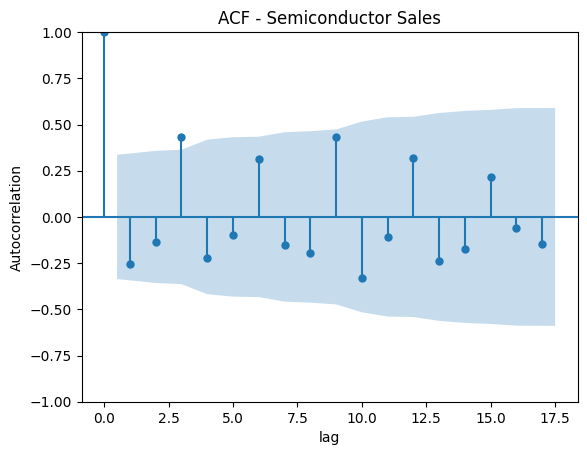

<Figure size 1200x500 with 0 Axes>

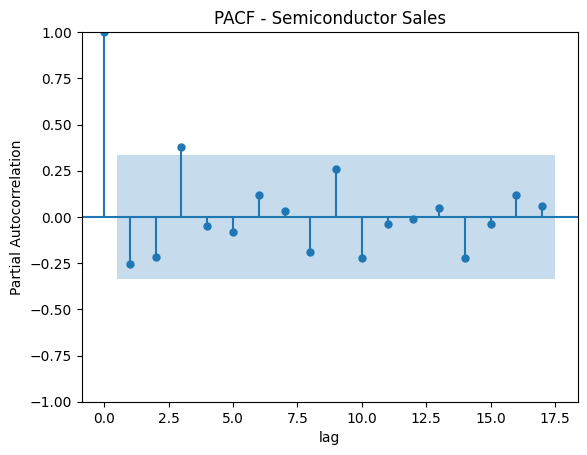

<Figure size 1200x500 with 0 Axes>

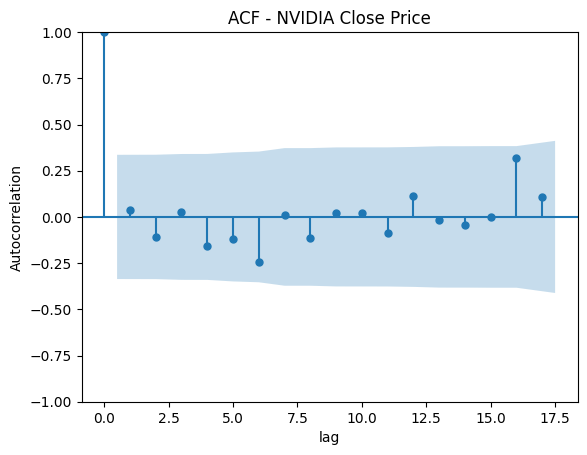

<Figure size 1200x500 with 0 Axes>

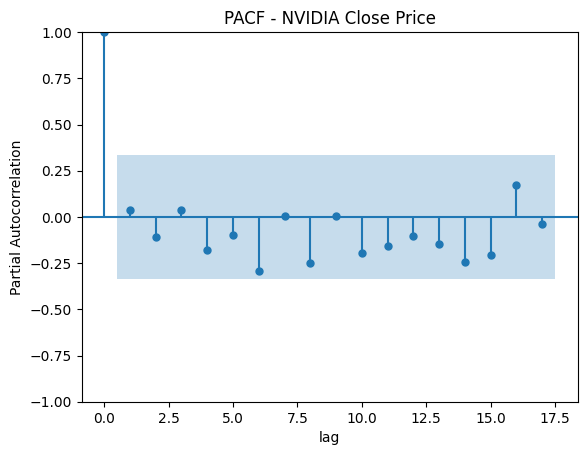

In [37]:
# OUTPUT:
plot_acf_pacf(final['Value_num'], "Semiconductor Sales")
plot_acf_pacf(final['Close'], "NVIDIA Close Price")

### Conclusions from my data:

**NVIDIA Close (differenced):** every ACF and PACF bar sits **inside** the band => no significant autocorrelation left. The differenced series behaves like **white noise** — no AR or MA structure to add, pointing to a **random walk (ARIMA(0,1,0))**. This is expected for a stock price (efficient-market behaviour: today's change doesn't predict tomorrow's).

**Semiconductor Sales (differenced):** the only bar outside the band is at **lag 3**, in *both* ACF and PACF => a candidate AR(3) or MA(3) term. This is a **repeating ~3-month rhythm in the changes** (wherever you start) — a plausible fit for quarterly business/ordering cycles in semiconductor billings.

**Caveat:** a *single* isolated spike at lag 3, with our small $n$ (~34) and wide band, may well be a **false positive** (at 95% confidence, ~1 in 20 lags crosses by chance). So treat lag 3 as a lead to test, not a confirmed signal — confirm it by fitting the model and checking the residuals are white noise.

### IMPORTANT: Choosing AR vs MA for Forecast Modelling!

**Sharp cut-off** = bars are significant up to some lag, then **abruptly** drop inside the band and stay there (no gradual fade). <br> **Decay (tailing off)** = bars shrink **gradually** over several lags before settling inside the band — a smooth downward trend rather than a sudden stop.

The decision rule is based on how the ACF and PACF **decay**, not just where a single lag pokes out:

| | ACF | PACF |
|---|---|---|
| **Pure AR(p)** | decays gradually (tails off) | cuts off sharply after lag $p$ |
| **Pure MA(q)** | cuts off sharply after lag $q$ | decays gradually (tails off) |
| **ARMA(p,q)** | tails off | tails off |

Practical test: **whichever plot cuts off sharply tells you the model type** — a sharp PACF cutoff => AR; a sharp ACF cutoff => MA. If both taper off gradually, you likely need both terms (ARMA).
<br>

**For our data:** neither ACF nor PACF shows a clean cutoff — just one isolated spike at lag 3 in both — so it's ambiguous by eye alone. In practice:
1. Fit a few candidates (AR(3), MA(3), ARMA(3,3)) and compare **AIC/BIC**.
2. Check residuals are white noise (Ljung-Box test).
3. Prefer the simplest model that passes — with $n \approx 34$, avoid overfitting with too many parameters.

### 6. Classical Forecasting

#### 6a. Baseline Forecasts - Naive & Mean Models

In [38]:
## Naive forecast: y(t-1) => y(t)
sia_set = final['Value_num']
nvidia_set = final['Close']

naive_forecast = sia_set.shift(1)

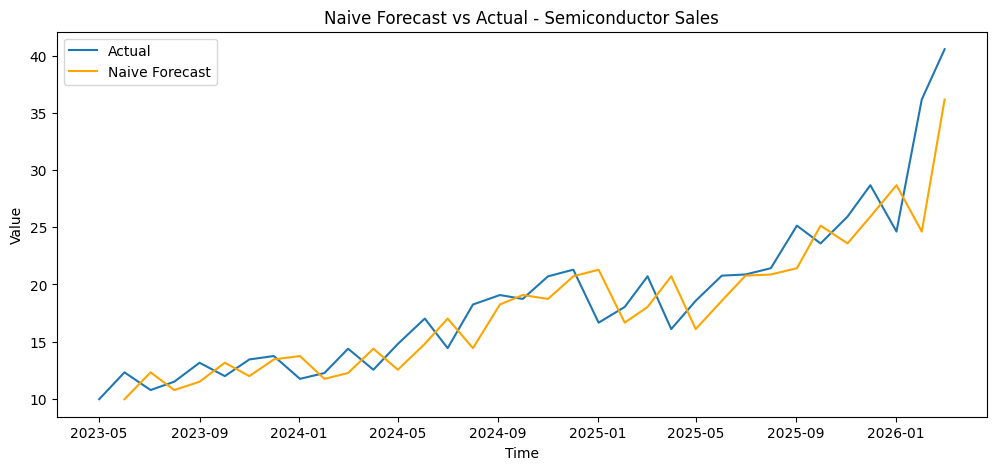

In [39]:
# OUTPUT for SIA:
plt.figure(figsize=(12,5))
plt.plot(sia_set, label="Actual")
plt.plot(naive_forecast, label="Naive Forecast", color='orange')
plt.title("Naive Forecast vs Actual - Semiconductor Sales")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## Naive forecast is a close approximation of actuals.

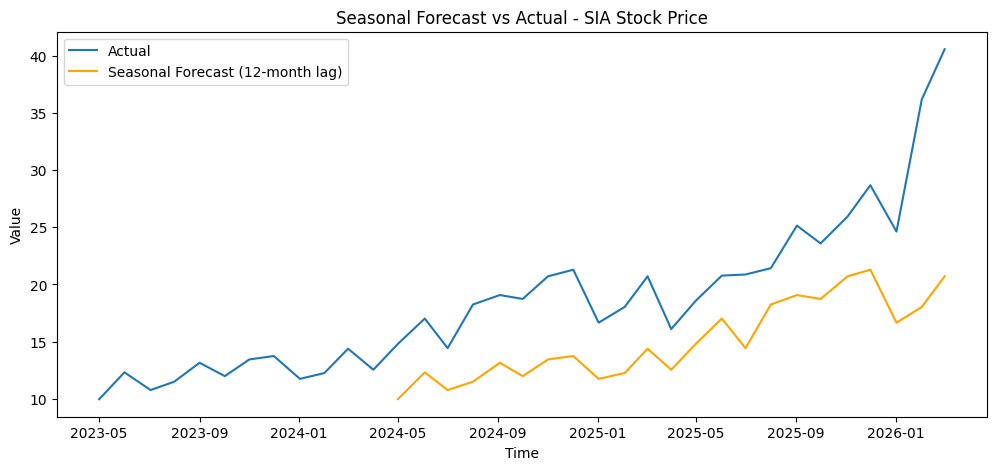

In [40]:
# seasonal_naive = value at a lag is current value, i.e. y(t-12) => y(t) for a 12-month lag.

seasonal_naive = sia_set.shift(12) # seasonal naive forecast: y(t-12) => y(t)

# OUTPUT for SIA:
plt.figure(figsize=(12,5))
plt.plot(sia_set, label="Actual")
plt.plot(seasonal_naive, label="Seasonal Forecast (12-month lag)", color='orange')
plt.title("Seasonal Forecast vs Actual - SIA Stock Price")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## Seasonal forecast is a POOR approximation of actuals.

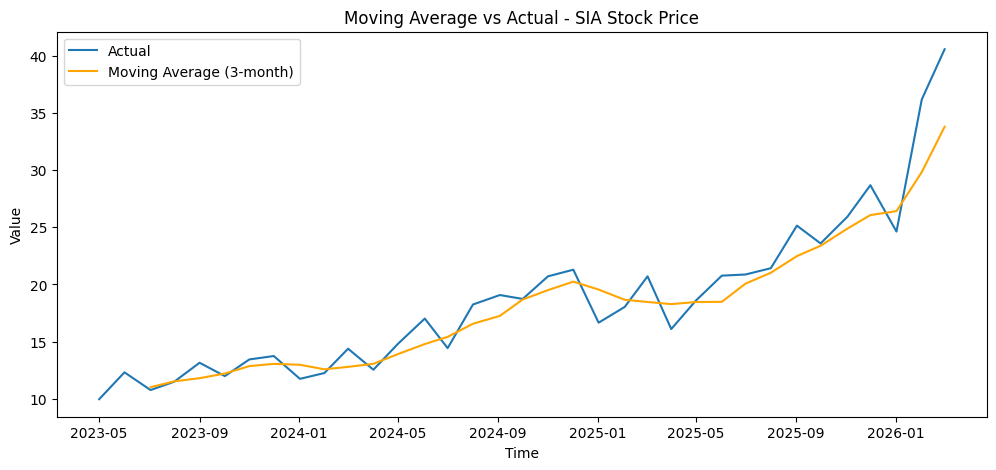

In [41]:
# Mean model = future value is average of last N values (e.g. last 3 months) => smooths out noise and captures underlying trend.

moving_avg = sia_set.rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(sia_set, label="Actual")
plt.plot(moving_avg, label="Moving Average (3-month)", color='orange')
plt.title("Moving Average vs Actual - SIA Stock Price")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## Moving average is a good but smoothened approximation of actuals. Reduced noise and reflects trend.
## Reacts slowly to sudden changes in the series.


### 5c. Simple & Exponential Smoothing


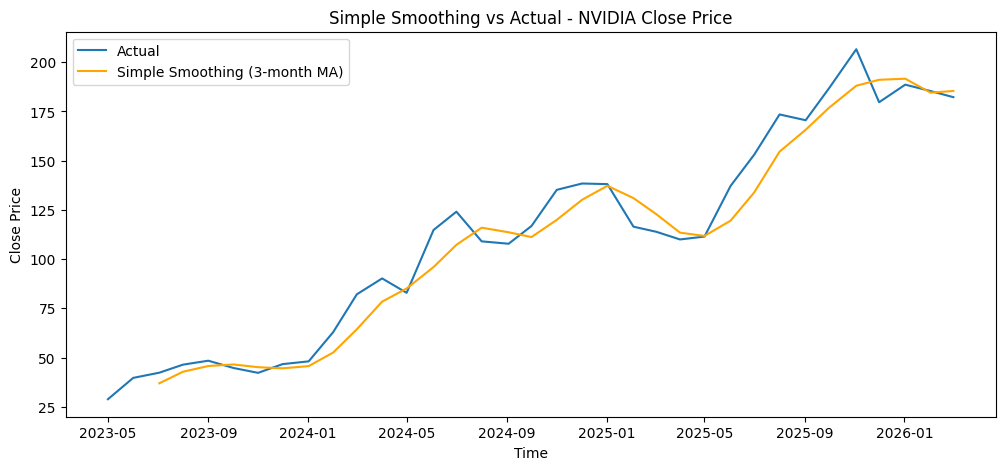

In [42]:
## ==== SIMPLE SMOOTHING (Simple Moving Average) ====
## Unweighted average of the last N points => every point in the window counts equally, so it reacts slowly to sudden changes.

simple_smooth = nvidia_set.rolling(window=3).mean() # 3-month rolling average of NVIDIA Close; each output = mean of current + previous 2 days, all weighted equally

## OUTPUT for NVIDIA - Simple Smoothing:
plt.figure(figsize=(12,5)) # new figure, 12x5 inches
plt.plot(nvidia_set, label="Actual") # plot the raw NVIDIA Close price series
plt.plot(simple_smooth, label="Simple Smoothing (3-month MA)", color='orange') # overlay the simple moving-average smoothed series
plt.title("Simple Smoothing vs Actual - NVIDIA Close Price") # chart title
plt.xlabel("Time") # x-axis label
plt.ylabel("Close Price") # y-axis label
plt.legend() # show the "Actual" / "Simple Smoothing" legend
plt.show() # render the plot


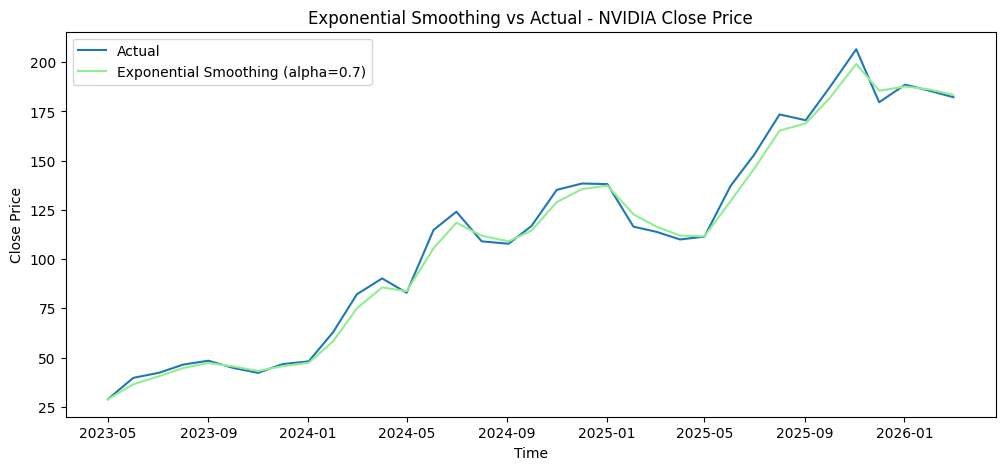

In [43]:
## ==== EXPONENTIAL SMOOTHING (Exponentially Weighted Moving Average) ====
## Weights decay exponentially the further back in time an observation is => most recent points matter most, so it reacts faster than the simple moving average.

exp_smooth = nvidia_set.ewm(alpha=0.7, adjust=False).mean() # alpha=0.7 => each new smoothed value = 0.7 * current price + 0.3 * previous smoothed value (recency-weighted)

## OUTPUT for NVIDIA - Exponential Smoothing:
plt.figure(figsize=(12,5)) # new figure, 12x5 inches
plt.plot(nvidia_set, label="Actual") # plot the raw NVIDIA Close price series
plt.plot(exp_smooth, label="Exponential Smoothing (alpha=0.7)", color='lightgreen') # overlay the exponentially smoothed series
plt.title("Exponential Smoothing vs Actual - NVIDIA Close Price") # chart title
plt.xlabel("Time") # x-axis label
plt.ylabel("Close Price") # y-axis label
plt.legend() # show the "Actual" / "Exponential Smoothing" legend
plt.show() # render the plot

## Simple smoothing (equal weights) lags behind sharp moves; exponential smoothing (decaying weights) tracks the actual series more closely since recent prices dominate the average.


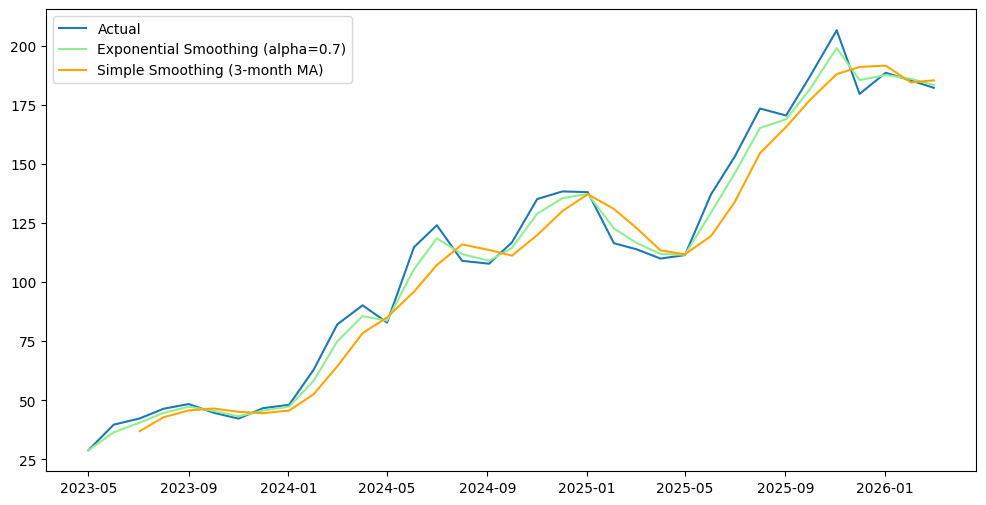

In [44]:
# Combined smoothened lines:
plt.figure(figsize=(12,6)) # new figure, 12x6 inches
plt.plot(nvidia_set, label="Actual") # plot the raw NVIDIA Close price series
plt.plot(exp_smooth, label="Exponential Smoothing (alpha=0.7)", color='lightgreen') # overlay the exponentially smoothed series
plt.plot(simple_smooth, label="Simple Smoothing (3-month MA)", color='orange') # overlay the simple moving-average smoothed series
plt.legend() # show the "Actual" / "Exponential Smoothing" legend
plt.show()

## The exponential smoothing line is better at capturing the overall trend and is also more reactive to sudden changes compared to the simple smoothing (moving average) line.

### 5d. Exponential Smoothing: Holt-Winters Method

Holt-Winters = **triple** exponential smoothing => captures level, trend, and seasonality, in addition to smoothing.

> Plain moving-average smoothing does not capture trend and seasonality.

**The three components:**

- **Level** — the current smoothed baseline value of the series, stripped of short-term noise (what plain exponential smoothing alone already estimates).
- **Trend** — the direction and rate at which the level is rising or falling from one period to the next.
- **Seasonality** — the repeating, fixed-length cycle of ups and downs around the level/trend (e.g. a yearly pattern), distinct from the long-term trend.

$$\text{Level (baseline)} + \text{Trend (direction)} + \text{Seasonality (additive OR multiplicative)} = \text{Forecast (predicted value)}$$


/Users/angadsahni/Desktop/0) Career/1) CV_Jobs/4) Projects/3) Time-series-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/angadsahni/Desktop/0) Career/1) CV_Jobs/4) Projects/3) Time-series-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


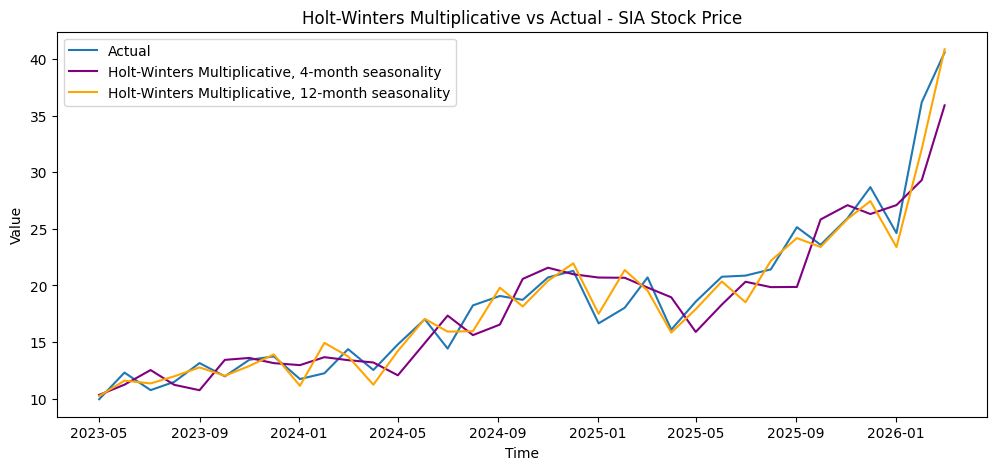

In [45]:

hw_mul_4 = ExponentialSmoothing(
    sia_set,
    trend='add', # trend adds a constant amount to the level each period, rather than compounding proportionally ('mul')
    seasonal='mul', # multiplicative seasonality
    seasonal_periods=4 # 4-month seasonality
).fit()

hw_mul_12 = ExponentialSmoothing(
    sia_set,
    trend='add', # trend adds a constant amount to the level each period, rather than compounding proportionally ('mul')
    seasonal='mul', # multiplicative seasonality
    seasonal_periods=12 # 12-month seasonality
).fit()

hw_mul_4_fitted = hw_mul_4.fittedvalues
hw_mul_12_fitted = hw_mul_12.fittedvalues

plt.figure(figsize=(12,5))
plt.plot(sia_set, label="Actual")
plt.plot(hw_mul_4_fitted, label="Holt-Winters Multiplicative, 4-month seasonality", color='purple')
plt.plot(hw_mul_12_fitted, label="Holt-Winters Multiplicative, 12-month seasonality", color='orange')
plt.title("Holt-Winters Multiplicative vs Actual - SIA Stock Price")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 12-month seasonality (orange) is a far superior fit to the actuals than 4-month seasonality (purple) => SIA stock price has a clear yearly seasonal pattern.

**Additive vs multiplicative — which to use?**

- **Additive**: seasonal swing stays roughly the **same absolute size** regardless of level (e.g. always +10 every December).
- **Multiplicative**: swing **scales with the level** (bigger absolute swings when the series is higher).

**Using MAE/RMSE/MAPE to decide:** fit one model with `seasonal='add'` and another with `seasonal='mul'`. For each, compute how far its fitted values are from the actuals:

$$MAE = \text{mean}(|actual - fitted|) \qquad RMSE = \sqrt{\text{mean}((actual - fitted)^2)} \qquad MAPE = \text{mean}\left(\left|\dfrac{actual - fitted}{actual}\right|\right) \times 100$$

All three are *average error size* — smaller means the model's predictions sit closer to the real values, i.e. a better fit. MAE/RMSE are in the series' own units (dollars, billings), while MAPE expresses the same error as a **percentage**, making it easier to judge "is this error big or small" without knowing the series' scale. So **compute all three for the additive model and for the multiplicative model**, then whichever model scores **lower** across them is the better-fitting one for this series.


### 5e. Forecast Evaluation - Fitted vs Actuals

In [46]:

results = pd.DataFrame(columns=['model', 'MAE', 'RMSE', 'MAPE']) # empty dataframe to collect each model's error metrics

models = {'hw_mul_4_fitted': hw_mul_4_fitted, 
          'hw_mul_12_fitted': hw_mul_12_fitted} # name -> fitted series, name typed once

for name, n in models.items():
    diff = sia_set - n

    mae = f"{diff.abs().mean():.2f}"
    rmse = f"{np.sqrt((diff**2).mean()):.2f}"
    mape = f"{((diff.abs() / sia_set).mean() * 100):.2f}"

    results.loc[len(results)] = [name, mae, rmse, f"{mape}%"] # append model name + its metrics as a new row

results
# RESULT: The 12-month seasonality model has lower score on every metric than the 4-month seasonality model (both multiplicative).


,model,MAE,RMSE,MAPE
0,hw_mul_4_fitted,2.03,2.50,10.76%
1,hw_mul_12_fitted,0.94,1.33,5.29%


### 5f. Advanced Exponential Smoothing
#### AR, MA, ARIMA Fundamentals

- **AR (AutoRegressive)** — forecasts $y_t$ from its own **past values** ($y_{t-1}, ..., y_{t-p}$).
- **MA (Moving Average)** — forecasts $y_t$ from **past forecast errors** ($e_{t-1}, ..., e_{t-q}$), not past values.
  - **Why errors?** Each error is the "shock" a model failed to explain at that point. If a shock's effect lingers into the next period(s) — e.g. a short-term correlated noise burst — including recent errors lets the model correct for that leftover influence, something raw past *values* alone can't capture.
  - **Use:** captures short-lived shock/noise dependence in the series, improving near-term forecasts beyond what AR's value-based memory gives.
- **ARIMA (AutoRegressive Integrated Moving Average)** — combines AR + MA, plus **differencing** ("Integrated", order $d$) to first make a non-stationary series stationary.

**AR** = uses past **values**. Predicts $y_t$ using $y_{t-1}, y_{t-2}, ..., y_{t-p}$ + noise (residuals) — $p$ = number of lagged observations included (AR order). AR captures **momentum**.

**MA** = uses past **forecast errors**. Predicts $y_t$ using noise (residuals, mistakes) from the previous $q$ periods — $q$ = number of lagged forecast errors included (MA order).

**AR + MA + Integration (differencing) = ARIMA** (AutoRegressive Integrated Moving Average) — combines AR + MA, plus differencing to first make a non-stationary series stationary.

$$ARIMA(p, d, q) \quad Parameters: p = \text{AR order (lagged values)}, \quad d = \text{differencing order}, \quad q = \text{MA order (lagged forecast errors)}$$

**Example:** $ARIMA(1,1,1)$ — $y_t$ depends on 1 lagged value ($p=1$) and 1 lagged forecast error ($q=1$), fitted on the series after differencing it once ($d=1$) to remove trend.

### 5g. Selecting Parameters (p,d,q) & Building ARIMA

**Parameters:** from the ACF and PACF graphs, we can determine the order of an $ARIMA(p,d,q)$ model:

- **$p$** = order of AR (Auto-Regressive) term = lag where **PACF** cuts off
- **$d$** = order of differencing = number of times the series is differenced to make it stationary
- **$q$** = order of MA (Moving Average) term = lag where **ACF** cuts off

> Poor parameter selection creates poor models.

Select $p$ and $q$ from the ACF and PACF plots respectively, and $d$ from how much differencing was needed to make the series stationary.

**Overfitting vs Underfitting:**

- **Overfitting** — too many parameters ($p$, $q$ too high): the model learns the noise/randomness in the training data, not just the signal. **Fits the training data almost perfectly but generalizes poorly**, giving unreliable forecasts on new/future data.
- **Underfitting** — too few parameters ($p$, $q$ too low): the model is too simple to capture the real structure (momentum, error-correction) in the series. Performs poorly even on the training data itself.

The goal is the simplest model that still fits well — enough parameters to capture genuine structure, not so many that it starts fitting noise.

> **For a deeper dive into what $p$ and $q$ actually mean, what a "parameter" is, and how AIC/BIC compute and penalize them — see [`ARIMA_parameter_details.md`](ARIMA_parameter_details.md).**

In [47]:
# Two ways of determining parameters:
# 1 - Visually from ACF and PACF plots.
# 2 - Using auto_arima() from the pmdarima library, which automatically selects the best ARIMA parameters based on AIC/BIC scores.

### 5g. SARIMA + SARIMAX: Seasonal & Exogenous Modeling

1. **SARIMA (Seasonal ARIMA)** — extends $ARIMA(p,d,q)$ with a second set of $(P,D,Q,s)$ terms that repeat the same AR/differencing/MA logic, but at the seasonal lag $s$ instead of lag 1: $SARIMA(p,d,q)(P,D,Q,s)$. So instead of only $y_{t-1}$, it also models $y_{t-s}$ (e.g. $s=12$ for monthly data with a yearly cycle) — capturing the repeating seasonal pattern that plain ARIMA can't, on top of the non-seasonal structure.

2. **Exogenous modeling (SARIMAX)** — adds external predictor variable(s) $X_t$ (e.g. the semiconductor billings series, when forecasting NVIDIA's price) into the equation alongside the AR/MA/seasonal terms. "Exogenous" just means "determined outside the model" — $X_t$ isn't itself being forecast, it's an input the model uses to help explain $y_t$, on the assumption that $X_t$ carries genuine predictive signal beyond $y$'s own history.

In [159]:
X = final['Value_num'].reset_index(drop=True) # drop the DatetimeIndex (no freq set) so SARIMAX/get_forecast can extend a plain integer index later
y = final['Returns'].reset_index(drop=True)

sarima_results = pd.DataFrame(columns=['season', 'AIC', 'BIC']) # empty dataframe to collect each seasonal period's scores

for season in (3, 4, 6, 12):
    # ARIMA parameters: p=AR order, d=differencing order, q=MA order
    p, d, q = 1, 0, 1 

    # Seasonal-ARIMA parameters: P=seasonal AR order, D=seasonal differencing order, Q=seasonal MA order, m=seasonal period (12 for monthly data with yearly seasonality)
    P, D, Q, m = 1, 0, 1, season 

    ## p,d,q are for non-seasonal components, while P,D,Q,m are for seasonal components, specifically defined by the seasonal period (m)
    sarima_model = SARIMAX(y, exog=X, order=(p, d, q), seasonal_order=(P, D, Q, m)) # exog=X included, since this is the SARIMAX (exogenous) section
    sarima_fit = sarima_model.fit()

    if(season == 12): # final output
        forecast_fit = sarima_fit
        check_fit = sarima_fit.summary()

    # AIC/BIC are attributes on the fitted result itself, not on .summary() (which only returns a printable report, not a field lookup):
    sarima_results.loc[len(sarima_results)] = [season, round(sarima_fit.aic, 2), round(sarima_fit.bic, 2)] # numeric, rounded to 2dp

display(sarima_results)
#display(check_fit)


/Users/angadsahni/Desktop/0) Career/1) CV_Jobs/4) Projects/3) Time-series-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/angadsahni/Desktop/0) Career/1) CV_Jobs/4) Projects/3) Time-series-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/angadsahni/Desktop/0) Career/1) CV_Jobs/4) Projects/3) Time-series-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,season,AIC,BIC
0,3.0,-29.74,-20.41
1,4.0,-29.55,-20.22
2,6.0,-31.15,-21.81
3,12.0,-32.38,-23.05


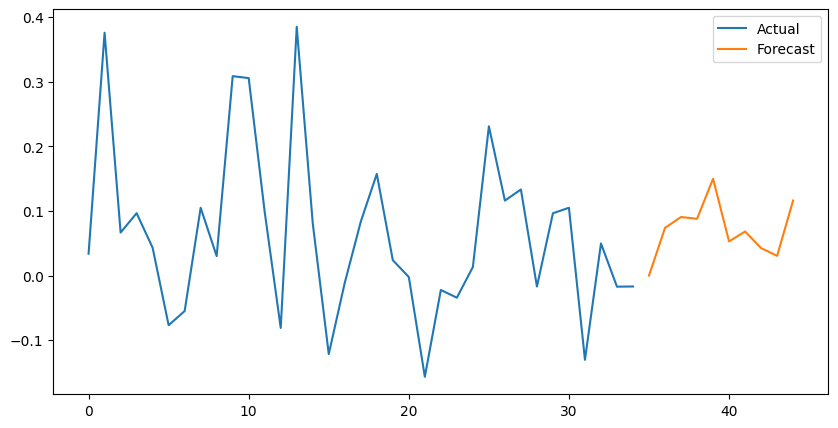

In [160]:
## Forecasting
future_X = X.iloc[-10:] # exogenous values to feed the next 10 forecast steps; using the last 10 known billings values as a stand-in for the future (no real future exog data available) -- .values avoids index-alignment issues

forecast = forecast_fit.get_forecast(
    steps=10, # forecast horizon: how many future periods to predict
    exog=future_X # exog = the EXOGenous predictor series (Value_num/billings) that the model was fit with -- SARIMAX needs one exog value per forecast step, since forecasting an exogenous model requires knowing (or assuming) X for the periods being forecast, not just y's own history
)

predicted = forecast.predicted_mean # the actual point forecasts (mean of the forecast distribution) for each of the 10 future steps


## OUTPUT:
plt.figure(figsize=(10,5))
plt.plot(y, label = 'Actual')
plt.plot(predicted, label='Forecast')
plt.legend()
plt.show()

### 5e. Residual Diagnostics & CIs